In [6]:
import matplotlib.pyplot as plt

In [7]:
class EVBattery:
    def __init__(self):
        # Initialize initial battery state
        self.soh = 100.0            # State of Health (%)
        self.capacity = 60          # Capacity in kWh
        self.temperature = 25.0     # Default temperature in °C
        self.cycles = 0             # Charge cycle counter
        
        # Lists to store daily data for analysis and plotting
        self.soh_history = []
        self.days_history = []

    def update_env(self, ambient_temp):
        # Update current ambient temperature
        self.temperature = ambient_temp

    def degrade(self):
        # Base capacity degradation per cycle
        cycle_damage = 0.005

        # Accelerated degradation for high ambient temperatures (>35°C)
        if self.temperature > 35:
            thermal_damage = 0.015
        else:
            thermal_damage = 0.0 

        # Apply total daily damage and prevent negative SOH values
        self.soh -= (cycle_damage + thermal_damage)
        self.soh = max(0.0, self.soh)

    def drive_and_charge(self, days, avg_temp):
        # Run daily simulation loop
        for day in range(days):
            self.update_env(avg_temp)
            self.cycles += 1
            self.degrade()

            # Record metrics for the current day
            self.soh_history.append(self.soh)
            self.days_history.append(day)

In [9]:
# Initialize battery object
my_battery = EVBattery()

# Get simulation parameters from user
days_input = int(input("Enter number of days: "))
temp_input = float(input("Enter temperature (°C): "))

# Run the simulation over the given time period
my_battery.drive_and_charge(days_input, temp_input)

# Display final performance metrics
print(f"""
After {days_input} days:
SOH: {my_battery.soh:.2f}%
Total Cycles: {my_battery.cycles}
Recorded Days Count: {len(my_battery.days_history)}
""")

Enter number of days:  85
Enter temperature (°C):  85



After 85 days:
SOH: 98.30%
Total Cycles: 85
Recorded Days Count: 85



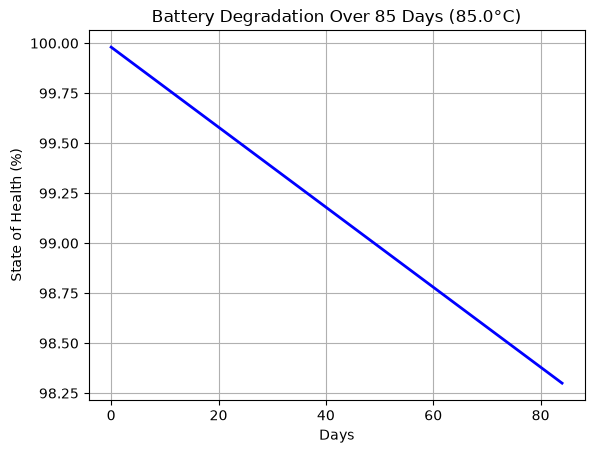

In [10]:
# Plot degradation curve over time
plt.plot(my_battery.days_history, my_battery.soh_history, color='blue', linewidth=2)
plt.xlabel("Days")
plt.ylabel("State of Health (%)")
plt.title(f"Battery Degradation Over {days_input} Days ({temp_input}°C)")
plt.grid(True)
plt.show()